In [59]:
import numpy as np                        # Μαθηματική/αριθμητική βιβλιοθήκη
import matplotlib.pyplot as plt           # Βιβλιοθήκη απεικονίσεων
from IPython.display import Audio         # βιβλιοθήκη για να "παίζουμε" ήχους (μεταξύ άλλων)
%matplotlib inline

## Άσκηση - Ιδανικά φίλτρα επιλογής συχνότητας

Ένα *επιλεκτικό ως προς τη συχνότητα* φίλτρο (frequency-selective filter) είναι ένα ΓΧΑ σύστημα συνεχούς χρόνου που αφήνει να περάσουν ορισμένες περιοχές συχνοτήτων του σήματος εισόδου (**ζώνη διέλευσης**) και αποκόπτει τις υπόλοιπες (**ζώνη αποκοπής**). Ανάλογα με το ποιες συχνότητες διατηρεί, διακρίνουμε τέσσερα βασικά είδη: 

το **χαμηλοπερατό**, το **υψιπερατό**, το **ζωνοπερατό** και το **ζωνοφρακτικό**.

Θα κατασκευάσουμε ένα σήμα $x(t)$ που αποτελείται από **πολλές ημιτονοειδείς συνιστώσες** σε διαφορετικές συχνότητες, και θα δούμε πρακτικά την επίδραση καθενός από τα τέσσερα ιδανικά φίλτρα πάνω σε αυτό. Επειδή ο υπολογιστής δεν μπορεί να αναπαραστήσει πραγματικά συνεχή σήματα, θα **προσομοιώσουμε** τον συνεχή χρόνο με ένα πολύ πυκνό άξονα χρόνου, βήματος $\Delta t$. Όσο μικρότερο το $\Delta t$, τόσο καλύτερη η προσέγγιση του συνεχούς άξονα - όπως ήδη πρέπει να ξέρετε από ασκήσεις προηγούμενων Κεφαλαίων.

Θα δουλέψουμε με δύο συμπληρωματικές οπτικές: 

- (α) την **αυστηρά ιδανική** απόκριση, την οποία υλοποιούμε στο πεδίο της συχνότητας (πολλαπλασιασμός $X(f)\,H(f)$), και 

- (β) την **υλοποιήσιμη** προσέγγιση μέσω αποκομμένης κρουστικής απόκρισης $h(t)$ ($\mathrm{sinc}$), όπου θα εμφανιστεί το φαινόμενο Gibbs.

### Οι αποκρίσεις σε συχνότητα των τεσσάρων ιδανικών φίλτρων
Για ένα ιδανικό φίλτρο η απόκριση πλάτους είναι $1$ στη ζώνη διέλευσης και $0$ στη ζώνη αποκοπής (απότομη μετάβαση), με μηδενική φάση.

**Χαμηλοπερατό (lowpass)** με συχνότητα αποκοπής $f_c$:

$$H_{LP}(f) = \begin{cases} 1, & |f| < f_c \\ 0, & |f| > f_c \end{cases}$$

**Υψιπερατό (highpass)** με συχνότητα αποκοπής $f_c$:
$$H_{HP}(f) = 1 - H_{LP}(f) = \begin{cases} 0, & |f| < f_c \\ 1, & |f| > f_c \end{cases}$$

**Ζωνοπερατό (bandpass)** με συχνότητες αποκοπής $f_{c1} < f_{c2}$:
$$H_{BP}(f) = \begin{cases} 1, & f_{c1} < |f| < f_{c2} \\ 0, & \text{αλλού} \end{cases}$$

**Ζωνοφρακτικό (bandstop)** με συχνότητες αποκοπής $f_{c1} < f_{c2}$:
$$H_{BS}(f) = 1 - H_{BP}(f) = \begin{cases} 0, & f_{c1} < |f| < f_{c2} \\ 1, & \text{αλλού} \end{cases}$$

Τα τέσσερα φίλτρα συνδέονται μεταξύ τους: το υψιπερατό είναι το «συμπλήρωμα» του χαμηλοπερατού, και το ζωνοφρακτικό το «συμπλήρωμα» του ζωνοπερατού. Επίσης, παρατηρήστε ότι 

$$H_{BP}(f) = H_{LP}(f_{c2}) - H_{LP}(f_{c1})$$

## i. Κατασκευή του σήματος εισόδου πολλαπλών συνιστωσών
(α') Κατασκευάστε ένα σήμα συνεχούς χρόνου που αποτελείται από **τέσσερις** συνημιτονοειδείς συνιστώσες, καλά διαχωρισμένες στο φάσμα:

$$x(t) = \cos(2\pi f_1 t) + \cos(2\pi f_2 t) + \cos(2\pi f_3 t) + \cos(2\pi f_4 t)$$

με $f_1 = 300$ Hz, $f_2 = 1200$ Hz, $f_3 = 2500$ Hz, $f_4 = 3500$ Hz. 

Επιλέξτε βήμα $\Delta t = 1/40000$ s και διάρκεια $0.5$ s. Σχεδιάστε ένα μικρό τμήμα του $x(t)$ και ακούστε το.

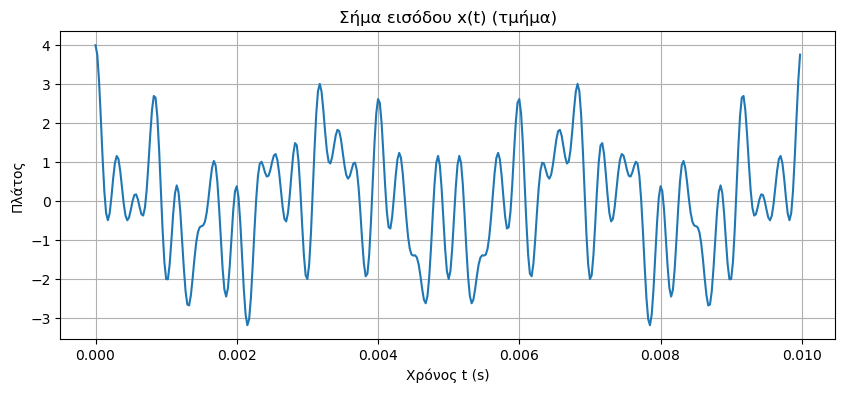

In [60]:
# i.α)
dt = 1/40000                  # βήμα χρόνου (s)
T  = 0.5                      # διάρκεια (s)
t  = np.arange(0, T, dt)      # συνεχής άξονας χρόνου

# Συχνότητες των συνιστωσών (Hz)
fk = np.array([300, 1200, 2500, 3500])

# Άθροισμα των τεσσάρων συνημιτόνων
x = np.zeros_like(t)
for f0 in fk:
    x = x + np.cos(2 * np.pi * f0 * t)

# Γραφική παράσταση ενός μικρού τμήματος στο χρόνο (τα πρώτα ~10 ms)
Nz = int(0.01 / dt)
plt.figure(figsize=(10, 4))
plt.title('Σήμα εισόδου x(t) (τμήμα)')
plt.plot(t[:Nz], x[:Nz])
plt.grid()
plt.xlabel('Χρόνος t (s)')
plt.ylabel('Πλάτος')
plt.show()

# Για να ακούσουμε το σήμα, το δειγματοληπτούμε με ρυθμό fs = 1/dt
Audio(x, rate=int(1/dt))

(β') Υπολογίστε το **φάσμα πλάτους** $|X(f)|$ του $x(t)$. Θυμηθείτε ότι ο μετασχ. Fourier συνεχούς χρόνου είναι 

$$X(f) = \int_{-\infty}^{+\infty} x(t) e^{-j2\pi f t} dt$$

Μια και από ασκήσεις προηγούμενου Κεφαλαίου, μπορούμε αριθμητικά να τον προσεγγίσουμε με τον Fast Fourier Transform (FFT) του δειγματοληπτημένου σήματος, με τον κατάλληλο άξονα συχνοτήτων ($\texttt{np.fft.rfftfreq}$ με βήμα $\Delta t$), ας το κάνυμε. Επιβεβαιώστε τις τέσσερις κορυφές στις $f_1, f_2, f_3, f_4$.

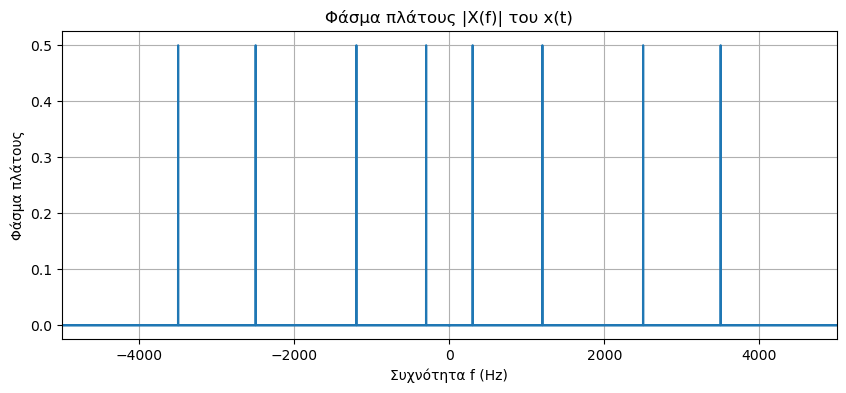

In [61]:
# i.β)
def magnitude_spectrum(x, dt):
    """Επιστρέφει τον άξονα συχνοτήτων (Hz) και το φάσμα πλάτους του x(t)."""
    N = len(x)
    X = np.fft.fft(x)                 # προσέγγιση του μετασχ. Fourier συνεχούς χρόνου
    f = np.fft.fftfreq(N, d=dt)       # άξονας συχνοτήτων σε Hz
    mag = np.abs(X) / N               # κανονικοποίηση του φάσματος πλάτους
    return f, mag

f, mag = magnitude_spectrum(x, dt)

plt.figure(figsize=(10, 4))
plt.title('Φάσμα πλάτους |X(f)| του x(t)')
plt.plot(f, mag)
plt.grid(True)
plt.xlabel('Συχνότητα f (Hz)')
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-5000, 5000)
plt.show()

Παρατηρούμε τέσσερις καθαρές κορυφές στα $\pm 300$, $\pm 1200$, $\pm 2500$ και $\pm 3500$ Hz, όσες και οι συνιστώσες. Στη συνέχεια κάθε φίλτρο θα κρατά ή θα αποκόπτει επιλεκτικά κάποιες από αυτές τις κορυφές.

## ii. Αυστηρά ιδανικό φιλτράρισμα στο πεδίο της συχνότητας

Η κρουστική απόκριση ενός ιδανικού φίλτρου είναι **άπειρης διάρκειας και μη αιτιατή** (όπως θα δούμε στο μέρος iii), άρα το ιδανικό φίλτρο δεν είναι υλοποιήσιμο ως πραγματικό (αιτιατό) σύστημα. Μπορούμε όμως να δούμε **ακριβώς** την ιδανική συμπεριφορά αν εργαστούμε στο πεδίο της συχνότητας: υπολογίζουμε το μετασχ. Fourier της εισόδου, $X(f)$, **μηδενίζουμε** το φάσμα στη ζώνη αποκοπής (πολλαπλασιασμός με $H(f)\in\{0,1\}$), και επιστρέφουμε στο χρόνο με τον αντίστροφο μετασχηματισμό Fourier.

(α') Γράψτε μια συνάρτηση $\texttt{ideal\_filter}$ που δέχεται το σήμα, το βήμα χρόνου $\Delta t$, το είδος του φίλτρου και τις συχνότητες αποκοπής (σε Hz), και επιστρέφει το φιλτραρισμένο σήμα.

In [62]:
# ii.α)
def ideal_filter(x, dt, kind, fc):
    """
    Αυστηρά ιδανικό φιλτράρισμα στο πεδίο της συχνότητας: Y(f) = X(f) H(f).
        x    : σήμα εισόδου (οιονεί συνεχές)
        dt   : βήμα χρόνου (s)
        kind : 'lp' (χαμηλοπερατό), 'hp' (υψιπερατό),
               'bp' (ζωνοπερατό),  'bs' (ζωνοφρακτικό)
        fc   : συχνότητα(-ες) αποκοπής σε Hz - αριθμός για lp/hp,
               ζεύγος [fc1, fc2] για bp/bs
    Επιστρέφει το φιλτραρισμένο σήμα (πραγματικό).
    """
    N = len(x)
    X = np.fft.fft(x)                       # μετασχ. Fourier
    freqs = np.fft.fftfreq(N, d=dt)         # συχνότητες κάθε συνιστώσας (Hz)
    af = np.abs(freqs)                      # |f|: το φάσμα είναι συμμετρικό

    if kind == 'lp':
        H = (af <= fc)
    elif kind == 'hp':
        H = (af >= fc)
    elif kind == 'bp':
        H = (af >= fc[0]) & (af <= fc[1])
    elif kind == 'bs':
        H = ~((af >= fc[0]) & (af <= fc[1]))
    else:
        raise ValueError('Άγνωστο είδος φίλτρου: ' + str(kind))

    Y = X * H                               # εφαρμογή της ιδανικής απόκρισης H(f)
    y = np.real(np.fft.ifft(Y))             # επιστροφή στο χρόνο
    return y

(β') **Χαμηλοπερατό.** Φιλτράρετε το $x(t)$ με ιδανικό χαμηλοπερατό φίλτρο συχνότητας αποκοπής $f_c = 1800$ Hz. Ποιες συνιστώσες αναμένετε να "επιβιώσουν"; Σχεδιάστε το φάσμα της εξόδου και ακούστε την.

Αφού $f_c = 1800$ Hz, περνούν οι συνιστώσες κάτω από τα $1800$ Hz, δηλαδή τα $300$ και $1200$ Hz, ενώ αποκόπτονται τα $2500$ και $3500$ Hz.

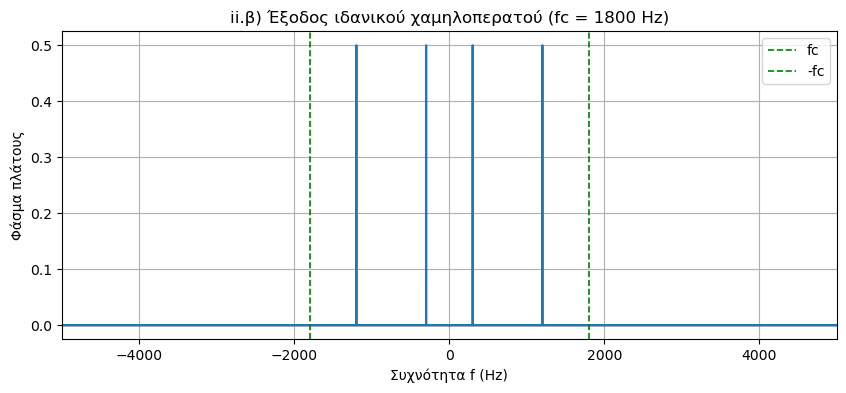

In [63]:
# ii.β) Χαμηλοπερατό
y_lp = ideal_filter(x, dt, 'lp', 1800)

f, mag = magnitude_spectrum(y_lp, dt)
plt.figure(figsize=(10, 4))
plt.title('ii.β) Έξοδος ιδανικού χαμηλοπερατού (fc = 1800 Hz)')
plt.plot(f, mag)
plt.grid(True)
plt.xlabel('Συχνότητα f (Hz)')
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-5000, 5000)
plt.axvline(1800, color='g', ls='--', lw=1.2, label='fc')
plt.axvline(-1800, color='g', ls='--', lw=1.2, label='-fc')
plt.legend()
plt.show()

Audio(y_lp, rate=int(1/dt))

(γ') **Υψιπερατό.** Επαναλάβετε με ιδανικό υψιπερατό φίλτρο, $f_c = 1800$ Hz.

Τώρα περνούν οι συνιστώσες πάνω από τα $1800$ Hz, δηλαδή τα $2500$ και $3500$ Hz, ενώ αποκόπτονται τα $300$ και $1200$ Hz.

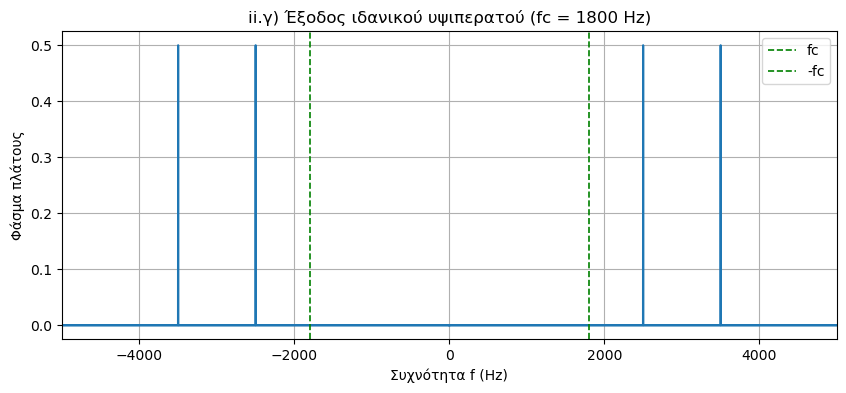

In [64]:
# ii.γ) Υψιπερατό
y_hp = ideal_filter(x, dt, 'hp', 1800)

f, mag = magnitude_spectrum(y_hp, dt)
plt.figure(figsize=(10, 4))
plt.title('ii.γ) Έξοδος ιδανικού υψιπερατού (fc = 1800 Hz)')
plt.plot(f, mag)
plt.grid(True)
plt.xlabel('Συχνότητα f (Hz)')
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-5000, 5000)
plt.axvline(1800, color='g', ls='--', lw=1.2, label='fc')
plt.axvline(-1800, color='g', ls='--', lw=1.2, label='-fc')
plt.legend()
plt.show()

Audio(y_hp, rate=int(1/dt))

(δ') **Ζωνοπερατό.** Φιλτράρετε το $x(t)$ με ιδανικό ζωνοπερατό φίλτρο με ζώνη διέλευσης $[f_{c1}, f_{c2}] = [800, 3000]$ Hz.

Μέσα στη ζώνη $[800, 3000]$ Hz βρίσκονται τα $1200$ και $2500$ Hz, τα οποία και περνούν. Τα $300$ Hz (κάτω από τη ζώνη) και τα $3500$ Hz (πάνω από τη ζώνη) αποκόπτονται.

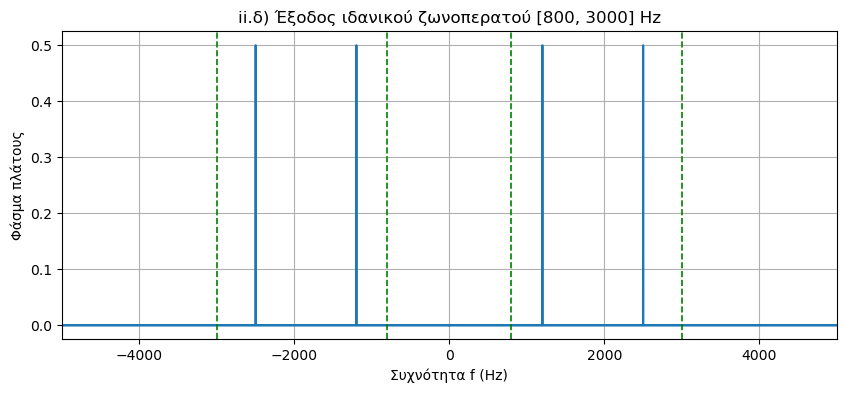

In [65]:
# ii.δ) Ζωνοπερατό
y_bp = ideal_filter(x, dt, 'bp', [800, 3000])

f, mag = magnitude_spectrum(y_bp, dt)
plt.figure(figsize=(10, 4))
plt.title('ii.δ) Έξοδος ιδανικού ζωνοπερατού [800, 3000] Hz')
plt.plot(f, mag)
plt.grid(True)
plt.xlabel('Συχνότητα f (Hz)')
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-5000, 5000)
plt.axvline(800, color='g', ls='--', lw=1.2)
plt.axvline(3000, color='g', ls='--', lw=1.2)
plt.axvline(-800, color='g', ls='--', lw=1.2)
plt.axvline(-3000, color='g', ls='--', lw=1.2)
plt.show()

Audio(y_bp, rate=int(1/dt))

(ε') **Ζωνοφρακτικό.** Τέλος, φιλτράρετε το $x(t)$ με ιδανικό ζωνοφρακτικό φίλτρο που αποκόπτει την ίδια ζώνη $[800, 3000]$ Hz.

Το ζωνοφρακτικό είναι το συμπλήρωμα του ζωνοπερατού: αποκόπτει τα $1200$ και $2500$ Hz και αφήνει να περάσουν τα $300$ και $3500$ Hz.

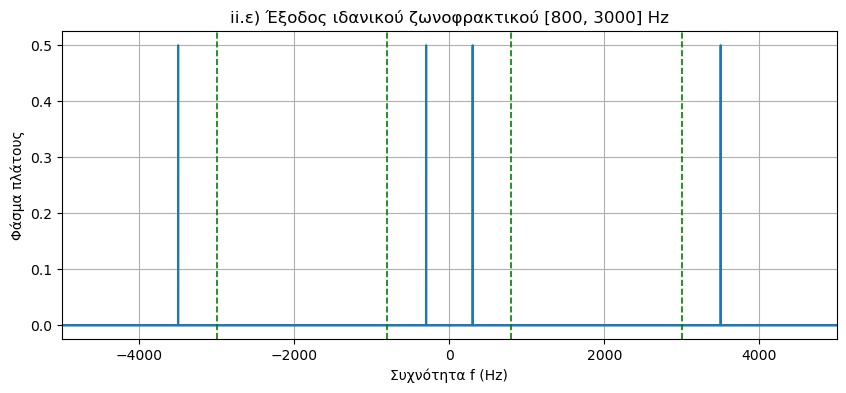

In [66]:
# ii.ε) Ζωνοφρακτικό
y_bs = ideal_filter(x, dt, 'bs', [800, 3000])

f, mag = magnitude_spectrum(y_bs, dt)
plt.figure(figsize=(10, 4))
plt.title('ii.ε) Έξοδος ιδανικού ζωνοφρακτικού [800, 3000] Hz')
plt.plot(f, mag)
plt.grid(True)
plt.xlabel('Συχνότητα f (Hz)')
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-5000, 5000)
plt.axvline(800, color='g', ls='--', lw=1.2)
plt.axvline(3000, color='g', ls='--', lw=1.2)
plt.axvline(-800, color='g', ls='--', lw=1.2)
plt.axvline(-3000, color='g', ls='--', lw=1.2)
plt.show()

Audio(y_bs, rate=int(1/dt))

## iii. Υλοποιήσιμη προσέγγιση: αποκομμένη κρουστική απόκριση (sinc)

Ας δούμε τώρα γιατί το ιδανικό φίλτρο δεν είναι υλοποιήσιμο. Η κρουστική απόκριση του ιδανικού βαθυπερατού προκύπτει ως ο αντίστροφος μετασχ. Fourier της $H_{LP}(f)$:

$$h_{LP}(t) = \int_{-f_c}^{f_c} e^{j2\pi f t} df = \frac{\sin(2\pi f_c t)}{\pi t} = 2 f_c\mathrm{sinc}(2 f_c t)$$

Πρόκειται για μια συνάρτηση $\mathrm{sinc}$ που εκτείνεται από το $-\infty$ έως το $+\infty$ και είναι **μη αιτιατή** (έχει τιμές για $t < 0$, δηλ. το φίλτρο θα έπρεπε να «γνωρίζει» το μέλλον της εισόδου). Για να πάρουμε ένα υλοποιήσιμο φίλτρο, **αποκόπτουμε** την $h_{LP}(t)$ σε ένα πεπερασμένο χρονικό παράθυρο $t \in [-T_h, T_h]$. Αυτή η αποκοπή αναπόφευκτα θα εισάγει σφάλματα σε σχέση με το ιδανικό φίλτρο.

(α') Κατασκευάστε την αποκομμένη κρουστική απόκριση ενός βαθυπερατού με $f_c = 1800$ Hz και μισό παράθυρο $T_h = 10$ ms, και σχεδιάστε την.

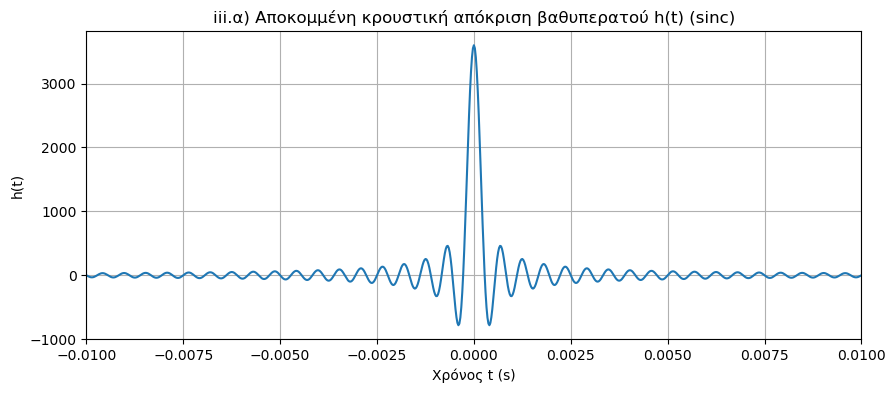

In [67]:
# iii.α) Αποκομμένη ιδανική κρουστική απόκριση (sinc)
fc = 1800                       # συχνότητα αποκοπής (Hz)
Th = 0.010                      # μισό παράθυρο αποκοπής (s)
th = np.arange(-Th, Th + dt/2, dt)   # συμμετρικός χρονικός άξονας

h_lp = 2 * fc * np.sinc(2 * fc * th)

plt.figure(figsize=(10, 4))
plt.title('iii.α) Αποκομμένη κρουστική απόκριση βαθυπερατού h(t) (sinc)')
plt.plot(th, h_lp)
plt.grid(True)
plt.xlabel('Χρόνος t (s)')
plt.ylabel('h(t)')
plt.xlim(-Th, Th)
plt.show()

(β') Υπολογίστε και σχεδιάστε την **απόκριση πλάτους** $|H(f)|$ του αποκομμένου φίλτρου, επιστρέφοντας προσωρινά στον αριθμητικός μετασχ. Fourier της κρουστικής απόκρισης $h(t)$: 

$$H(f) = \int h(t) e^{-j2\pi f t} dt \approx \Delta t \sum_n h(t_n)e^{-j2\pi f t_n}$$

Συγκρίνετέ την με την ιδανική περίπτωση. Τι παρατηρείτε;

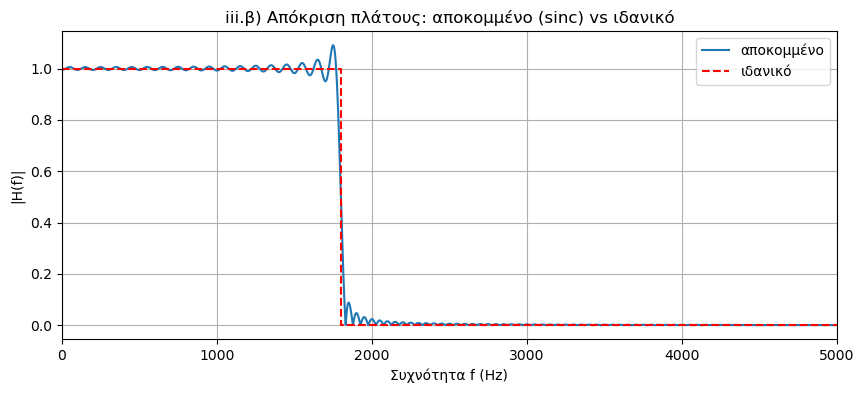

In [68]:
# iii.β) Απόκριση πλάτους του αποκομμένου φίλτρου (αριθμητικός μετασχ. Fourier)
fgrid = np.linspace(0, 5000, 2000)                 # άξονας συχνοτήτων (Hz)

E = np.exp(-1j * 2 * np.pi * np.outer(fgrid, th))  
Hf = dt * (E @ h_lp)

plt.figure(figsize=(10, 4))
plt.title('iii.β) Απόκριση πλάτους: αποκομμένο (sinc) vs ιδανικό')
plt.plot(fgrid, np.abs(Hf), label='αποκομμένο')
plt.plot([0, fc, fc, 5000], [1, 1, 0, 0], 'r--', label='ιδανικό')
plt.grid(True)
plt.xlabel('Συχνότητα f (Hz)')
plt.ylabel('|H(f)|')
plt.xlim(0, 5000)
plt.legend()
plt.show()

Βλέπουμε ότι το υλοποιήσιμο φίλτρο **δεν** έχει απότομη μετάβαση: υπάρχει μια ζώνη μετάβασης πεπερασμένου πλάτους γύρω από τα $1800$ Hz, και - το πιο χαρακτηριστικό - εμφανίζονται **κυματώσεις (ripples)** τόσο στη ζώνη διέλευσης όσο και στη ζώνη αποκοπής. Πρόκειται για το **φαινόμενο Gibbs** στο χώρο της συχνότητας, άμεση συνέπεια της απότομης αποκοπής της $\mathrm{sinc}()$ στο χρόνο (ισοδύναμα, της συνέλιξης του ιδανικού φίλτρου με το φάσμα του τετραγωνικού παραθύρου). Αυξάνοντας την τιμή του $T_h$ η μετάβαση γίνεται οξύτερη, όμως το **ύψος** της κυμάτωσης κοντά στην ασυνέχεια δεν μηδενίζεται ποτέ (μένει ~$9\%$)· χρειάζεται κατάλληλη παραθύρωση (π.χ. Hamming) για να το μειώσουμε.

(γ') Φιλτράρετε το σήμα $x(t)$ με το αποκομμένο χαμηλοπερατό. Η έξοδος είναι η **συνέλιξη** 

$$y(t) = (x * h)(t) = \int x(\tau) h(t-\tau) d\tau$$

την οποία προσεγγίζουμε αριθμητικά ως $\Delta t \cdot (\texttt{np.convolve})$, όπως θα έχετε δει σε σχετική άσκηση του 4ου Κεφαλαίου.

Συγκρίνετε το φάσμα της εξόδου με εκείνο του αυστηρά ιδανικού βαθυπερατού του μέρους ii.β.

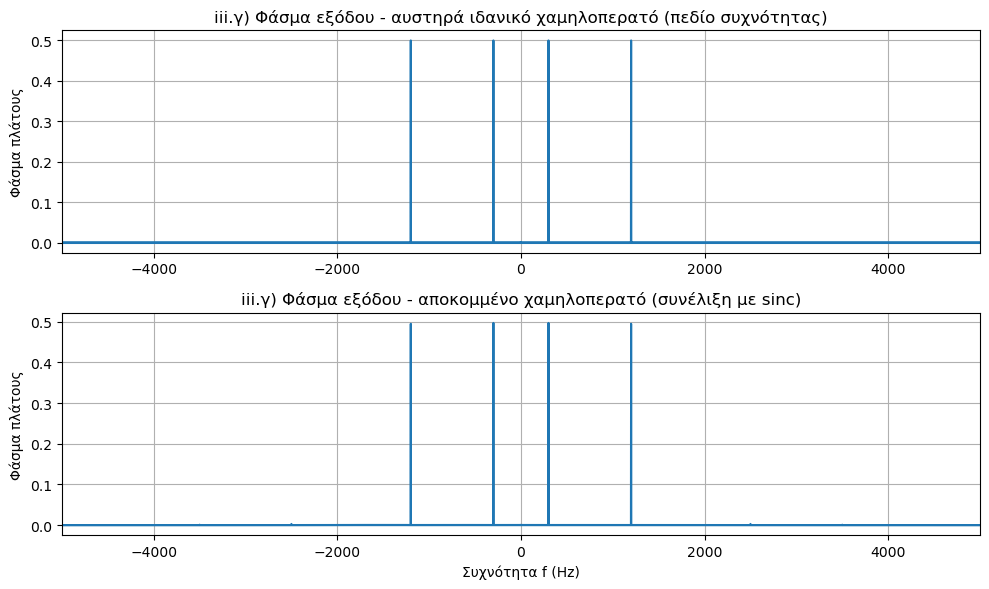

In [71]:
# iii.γ) Φιλτράρισμα μέσω συνέλιξης με το αποκομμένο h(t)
y_conv = dt * np.convolve(x, h_lp, mode='same')   # ο παράγοντας dt προσεγγίζει το ολοκλήρωμα

f1, mag1 = magnitude_spectrum(y_lp,   dt)    # αυστηρά ιδανικό (ii.β)
f2, mag2 = magnitude_spectrum(y_conv, dt)    # αποκομμένο, μέσω συνέλιξης

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.title('iii.γ) Φάσμα εξόδου - αυστηρά ιδανικό χαμηλοπερατό (πεδίο συχνότητας)')
plt.plot(f1, mag1)
plt.grid(True)
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-5000, 5000)

plt.subplot(2, 1, 2)
plt.title('iii.γ) Φάσμα εξόδου - αποκομμένο χαμηλοπερατό (συνέλιξη με sinc)')
plt.plot(f2, mag2)
plt.grid(True)
plt.xlabel('Συχνότητα f (Hz)')
plt.ylabel('Φάσμα πλάτους')
plt.xlim(-5000, 5000)
plt.tight_layout()
plt.show()

Audio(y_conv, rate=int(1/dt))

Και τα δύο κρατούν τις συνιστώσες $300$ και $1200$ Hz. Στο ιδανικό φίλτρο οι συνιστώσες της ζώνης αποκοπής μηδενίζονται **ακριβώς**. Στην αποκομμένη υλοποίηση παραμένουν μικρά ίχνη τους (λόγω του ripple στη ζώνη αποκοπής), ενώ τα πλάτη στη ζώνη διέλευσης δεν είναι απολύτως ίσα με $0.5$. 

Επιπλέον, η αιτιατή εκδοχή του φίλτρου (με το παράθυρο να ξεκινά στο $t=0$) εισάγει **καθυστέρηση** $T_h$ - εδώ, με συμμετρικό παράθυρο και $\texttt{mode='same'}$, κρατήσαμε το σήμα ευθυγραμμισμένο.

Συνοψίζοντας:

- Το **ιδανικό** φίλτρο ($|H(f)| = 1$ ή $0$, μηδενική ζώνη μετάβασης) υπάρχει μόνο ως μαθηματική ιδεατή περιγραφή. Η κρουστική του απόκριση $h(t)$ είναι άπειρης διάρκειας και μη αιτιατή, άρα δεν υλοποιείται σε πραγματικό χρόνο. Το προσομοιώσαμε «ακριβώς» μόνο επειδή δουλέψαμε εκ των υστέρων (offline) στο πεδίο της συχνότητας ολόκληρου του σήματος.

- Κάθε **υλοποιήσιμο** φίλτρο έχει πεπερασμένη ζώνη μετάβασης, κάποια κυμάτωση, και μη μηδενική καθυστέρηση. Η αποκοπή της $\mathrm{sinc}$ εισάγει το φαινόμενο Gibbs στο χώρο της συχνότητας. Στην πράξη, σχεδιάζουμε αναλογικά φίλτρα (π.χ. Butterworth, Chebyshev, ελλειπτικά) ή, μετά από δειγματοληψία, ψηφιακά φίλτρα, που ανταλλάσσουν αυστηρότητα μετάβασης, κυμάτωση και τάξη/πολυπλοκότητα. Σε Κεφάλαιο που ακολουθεί θα σχεδιάσετε ένα τέτοιο φίλτρο!

Το βασικό συμπέρασμα είναι ότι τα τέσσερα ιδανικά φίλτρα ορίζουν τον **στόχο** (ποιες συχνότητες θέλουμε να κρατήσουμε), ενώ η πραγματική σχεδίαση φίλτρου είναι το πρόβλημα της **προσέγγισης** αυτού του στόχου με πεπερασμένους πόρους.

---

---